In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/twitter-sentiment-analysis-hatred-speech/train.csv
/kaggle/input/twitter-sentiment-analysis-hatred-speech/test.csv
/kaggle/input/hate-speech-and-offensive-language-dataset/labeled_data.csv


In [2]:
import nltk
import numpy as np
import pandas as pd
import re
import seaborn as sns


In [3]:
hate=pd.read_csv("/kaggle/input/twitter-sentiment-analysis-hatred-speech/train.csv")

In [4]:
hate

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


<AxesSubplot:xlabel='label', ylabel='count'>

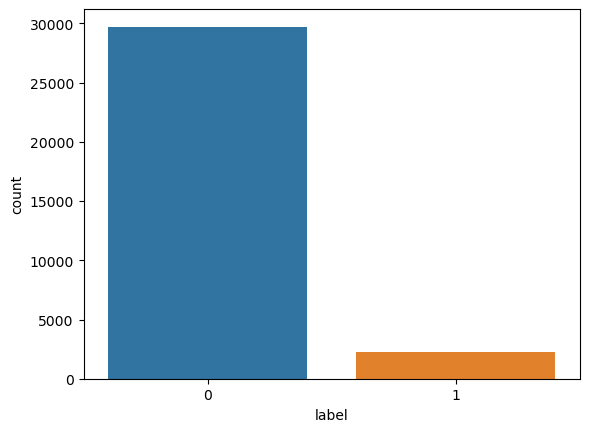

In [5]:
sns.countplot(x='label',data=hate)

In [6]:
hate.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

In [7]:
hate.drop('id',axis=1,inplace=True)

In [8]:
hate_offensive=pd.read_csv("/kaggle/input/hate-speech-and-offensive-language-dataset/labeled_data.csv")

In [9]:
hate_offensive

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [10]:
hate_offensive.isnull().sum()

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [11]:
hate_offensive.drop(['Unnamed: 0','count','hate_speech','offensive_language','neither'],axis=1,inplace=True)

In [12]:
hate_offensive.head(10)

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...
8,1,""" &amp; you might not get ya bitch back &amp; ..."
9,1,""" @rhythmixx_ :hobbies include: fighting Maria..."


<AxesSubplot:xlabel='class', ylabel='count'>

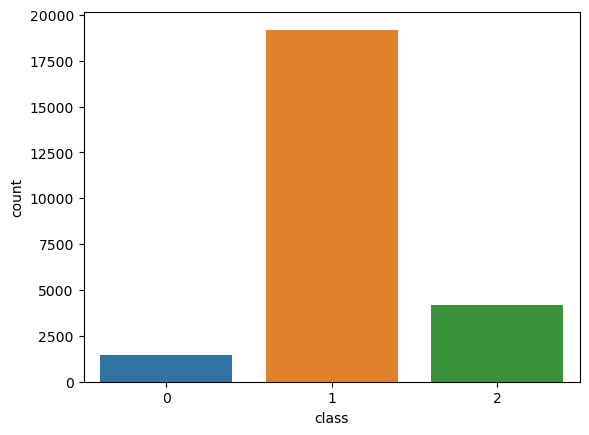

In [13]:
sns.countplot(x='class',data=hate_offensive)

In [14]:
hate_offensive[hate_offensive['class']==0]['class']=1

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [15]:
hate_offensive.head(5)

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [16]:
hate_offensive['class'].unique()

array([2, 1, 0])

In [17]:
hate_offensive[hate_offensive['class']==0]

,class,tweet
85,0,"""@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1..."
89,0,"""@CB_Baby24: @white_thunduh alsarabsss"" hes a ..."
110,0,"""@DevilGrimz: @VigxRArts you're fucking gay, b..."
184,0,"""@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL..."
202,0,"""@NoChillPaz: ""At least I'm not a nigger"" http..."
...,...,...
24576,0,this guy is the biggest faggot omfg
24685,0,which one of these names is more offensive kik...
24751,0,you a pussy ass nigga and I know it nigga.
24776,0,you're all niggers


In [18]:
hate_offensive["class"].replace({0: 1}, inplace=True)

In [19]:
hate_offensive['class'].unique()

array([2, 1])

<AxesSubplot:xlabel='class', ylabel='count'>

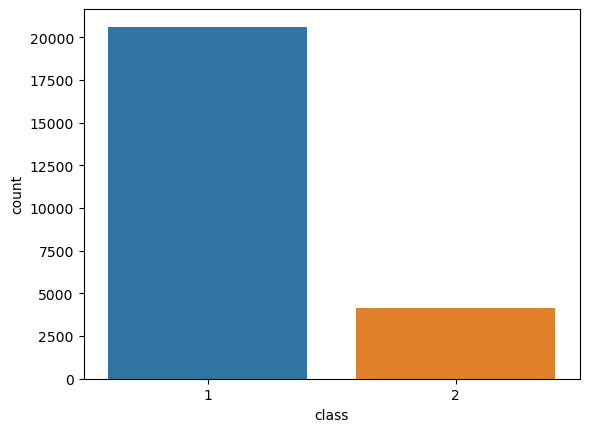

In [20]:
sns.countplot(x='class',data=hate_offensive)

In [21]:
hate_offensive["class"].replace({2: 0}, inplace=True)

<AxesSubplot:xlabel='class', ylabel='count'>

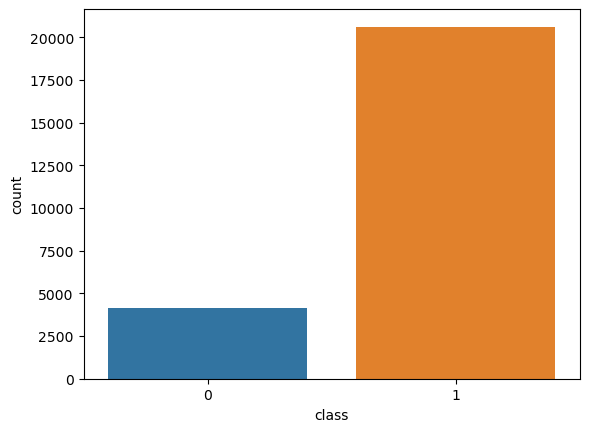

In [22]:
sns.countplot(x='class',data=hate_offensive)

In [23]:
hate_offensive.rename(columns ={'class':'label'}, inplace = True)

In [24]:
hate_offensive.head()

,label,tweet
0,0,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [25]:
frame=[hate,hate_offensive]
df = pd.concat(frame)

In [26]:
df.head(10)

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation
5,0,[2/2] huge fan fare and big talking before the...
6,0,@user camping tomorrow @user @user @user @use...
7,0,the next school year is the year for exams.ð...
8,0,we won!!! love the land!!! #allin #cavs #champ...
9,0,@user @user welcome here ! i'm it's so #gr...


<AxesSubplot:xlabel='label', ylabel='count'>

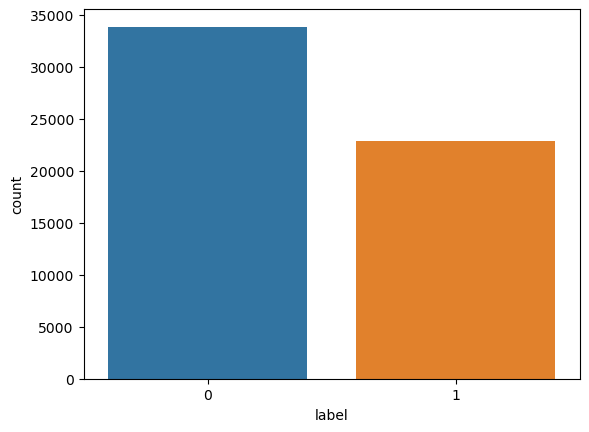

In [27]:
 sns.countplot(x='label',data=df)

In [28]:
df.shape

(56745, 2)

In [29]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
stemmer = nltk.SnowballStemmer("english")
from nltk.corpus import stopwords
import string
stopword=set(stopwords.words('english'))

In [31]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = [word for word in text.split(' ') if word not in stopword]
    text=" ".join(text)
    text = [stemmer.stem(word) for word in text.split(' ')]
    text=" ".join(text)
    return text

In [32]:
df['tweet']=df['tweet'].apply(clean_text)

In [33]:
df.to_csv('test.csv',index=False)

In [34]:
df.head()

,label,tweet
0,0,user father dysfunct selfish drag kid dysfunc...
1,0,user user thank lyft credit cant use caus dont...
2,0,bihday majesti
3,0,model love u take u time urð± ððð...
4,0,factsguid societi motiv


In [35]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
def make_wordcloud(df):
    comment_words=""
    for val in df.tweet: 
        val = str(val).lower()

      
        comment_words += " ".join(val)+" "
    print(comment_words[0:100])
    wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,min_font_size = 10).generate(comment_words)
  
    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

In [37]:
df.to_csv('testing.csv',index=False)
df

,label,tweet
0,0,user father dysfunct selfish drag kid dysfunc...
1,0,user user thank lyft credit cant use caus dont...
2,0,bihday majesti
3,0,model love u take u time urð± ððð...
4,0,factsguid societi motiv
...,...,...
24778,1,yous muthafin lie coreyemanuel right tl tras...
24779,0,youv gone broke wrong heart babi drove redneck...
24780,1,young buck wanna eat dat nigguh like aint fuck...
24781,1,youu got wild bitch tellin lie


In [38]:
x=df['tweet']
y=df['label']
type(x)

pandas.core.series.Series

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


#print(len(x_train), len(y_train))
#print(len(x_test), len(y_test))
type(x_train)

pandas.core.series.Series

In [40]:
x_train

20376    happi   happi choic choos feelinnostalg  santa...
21595           reason cheat show bitch kind dick girl get
22145                      song may basic bitch mood boost
14400    user judg aaron perski mani other remov asap m...
12903    let tell ya follow boogi twitter best decis iv...
                               ...                        
22381    ummmso happi fairi appar took crap twitter mad...
6196        ivanrabago least put caption steal pic fag lol
860      black professor make assumpt entir race whilst...
15795    lgbtqhatetrumppay total liber trash   amp path...
24460                                   sorri wrong bitch 
Name: tweet, Length: 39721, dtype: object

In [41]:
x_test

12238    kim k alright honest mani nigga id rather mile...
14377    rt bigjonbul star wink know smile see two love...
17207    rt sassymermaidxo   sister shittin hos vsamon ...
22168    tell  lookin ass nigga  ima crazi bitch that n...
18801     day ago  celebr nation ice tea day starbuck t...
                               ...                        
19253     go check blog blog blogger fashion workout   ...
6643                                fuck bitch where sleev
25895    begun someth new page amp super     daili taro...
24323    one day im like harri style hot next day tf fa...
20496    spread love amp happi ðð blacklivesmatt ...
Name: tweet, Length: 17024, dtype: object

FEATURE EXTRACTION: WORD2VEC

In [42]:
from gensim.models import Word2Vec
import nltk
nltk.download('punkt')

# Tokenize the text data
x_train_tokenized = [nltk.word_tokenize(text) for text in x_train]
x_test_tokenized = [nltk.word_tokenize(text) for text in x_test]

# Train the Word2Vec model on the tokenized text data
model = Word2Vec(sentences=x_train_tokenized, vector_size=100, window=5, min_count=1, workers=4)

# Convert text data to numerical representation using the trained Word2Vec model
x_train_w2v = []
for sentence in x_train_tokenized:
    sentence_w2v = []
    for word in sentence:
        if word in model.wv:
            sentence_w2v.append(model.wv[word])
    x_train_w2v.append(sentence_w2v)

x_test_w2v = []
for sentence in x_test_tokenized:
    sentence_w2v = []
    for word in sentence:
        if word in model.wv:
            sentence_w2v.append(model.wv[word])
    x_test_w2v.append(sentence_w2v)


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [43]:

from tensorflow.keras.preprocessing.sequence import pad_sequences


# Pad the Word2Vec embeddings for each tweet to a fixed length
max_tweet_length = 100 # or any other maximum length you want
x_train_padded = pad_sequences(x_train_w2v, maxlen=max_tweet_length, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test_w2v, maxlen=max_tweet_length, padding='post', truncating='post')

# Flatten the Word2Vec embeddings
x_train_flattened = x_train_padded.reshape((x_train_padded.shape[0], -1))
x_test_flattened = x_test_padded.reshape((x_test_padded.shape[0], -1))




In [48]:
# Train the logistic regression model
clf = LogisticRegression(random_state=42)
clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vlr = clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vlr)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vlr))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_w2vlr))

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Accuracy: 0.8993186090225563
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     10101
           1       0.93      0.81      0.87      6923

    accuracy                           0.90     17024
   macro avg       0.91      0.89      0.89     17024
weighted avg       0.90      0.90      0.90     17024

Confusion Matrix:
[[9678  423]
 [1291 5632]]


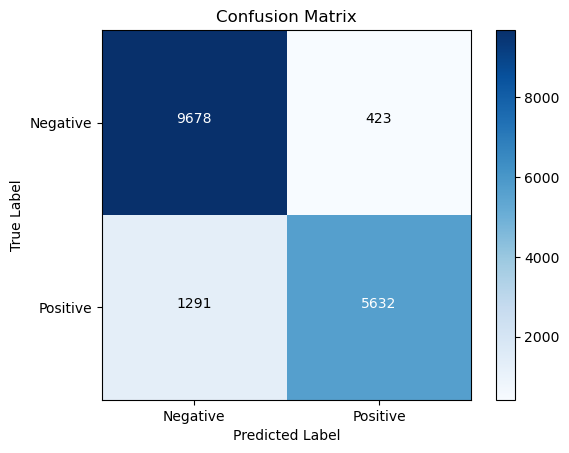

In [49]:
cm = confusion_matrix(y_test, y_pred_w2vlr)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [50]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vknn = clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vknn)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vknn))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_w2vknn))

Accuracy: 0.8809328007518797
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     10101
           1       0.87      0.83      0.85      6923

    accuracy                           0.88     17024
   macro avg       0.88      0.87      0.88     17024
weighted avg       0.88      0.88      0.88     17024

Confusion Matrix:
[[9261  840]
 [1187 5736]]


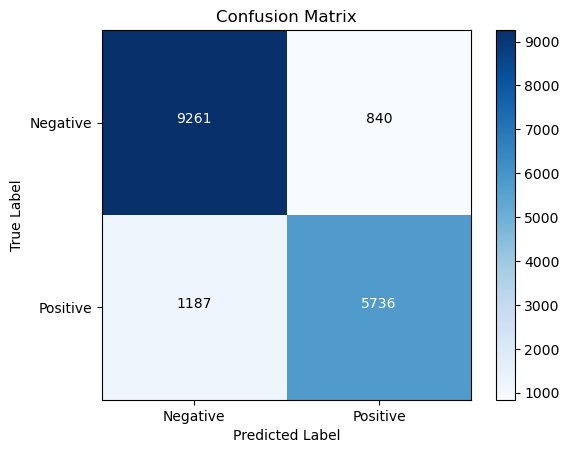

In [51]:
cm = confusion_matrix(y_test, y_pred_w2vknn)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [53]:
from sklearn.naive_bayes import GaussianNB
# Train the Gaussian Naive Bayes model
clf = GaussianNB()
clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vnb = clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vnb)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vnb))

Accuracy: 0.8467457706766918
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87     10101
           1       0.82      0.80      0.81      6923

    accuracy                           0.85     17024
   macro avg       0.84      0.84      0.84     17024
weighted avg       0.85      0.85      0.85     17024



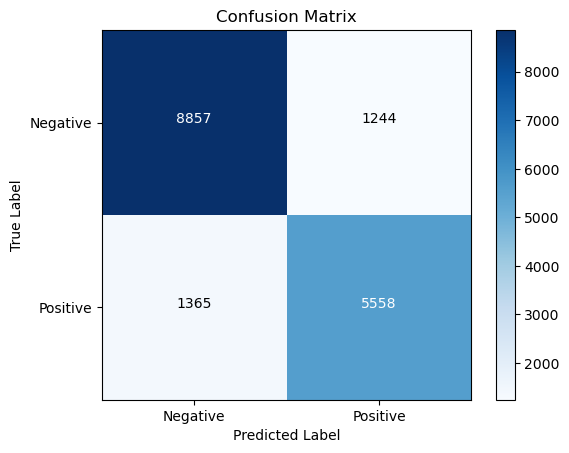

In [54]:
cm = confusion_matrix(y_test, y_pred_w2vnb)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [55]:
from sklearn.tree import DecisionTreeClassifier
# Train the Decision Tree model
clf = DecisionTreeClassifier()
clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vdt = clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vdt)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vdt))

Accuracy: 0.8498002819548872
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87     10101
           1       0.82      0.81      0.81      6923

    accuracy                           0.85     17024
   macro avg       0.84      0.84      0.84     17024
weighted avg       0.85      0.85      0.85     17024



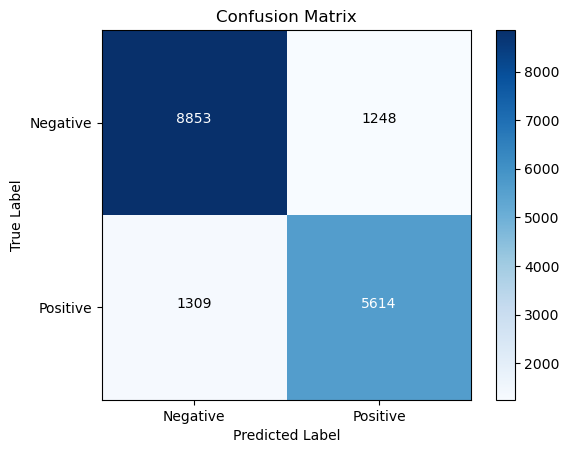

In [56]:
cm = confusion_matrix(y_test, y_pred_w2vdt)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Train the Random Forest model
clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vrf = clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vrf)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vrf))

Accuracy: 0.9013157894736842
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     10101
           1       0.92      0.83      0.87      6923

    accuracy                           0.90     17024
   macro avg       0.91      0.89      0.90     17024
weighted avg       0.90      0.90      0.90     17024



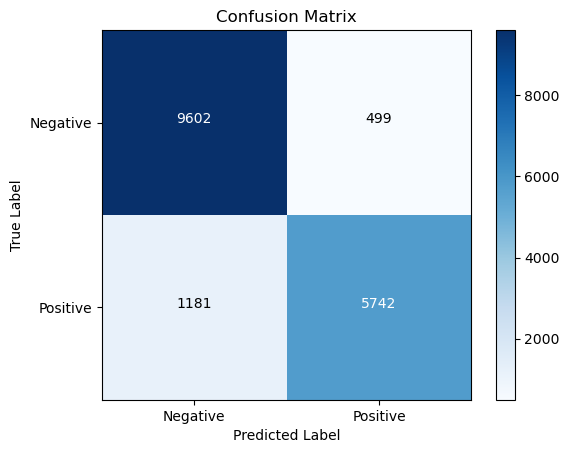

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred_w2vrf)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [56]:
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression()
nb = GaussianNB()
dt = DecisionTreeClassifier()

# Initialize the voting classifier
voting_clf = VotingClassifier(estimators=[('lr', lr), ('nb', nb), ('dt', dt)], voting='hard')

# Train the ensemble model
voting_clf.fit(x_train_flattened, y_train)

# Predict on the test data
y_pred_w2vvc = voting_clf.predict(x_test_flattened)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_w2vvc)
print("Accuracy:", accuracy)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_w2vvc))

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


Accuracy: 0.8870418233082706
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     10101
           1       0.86      0.87      0.86      6923

    accuracy                           0.89     17024
   macro avg       0.88      0.88      0.88     17024
weighted avg       0.89      0.89      0.89     17024



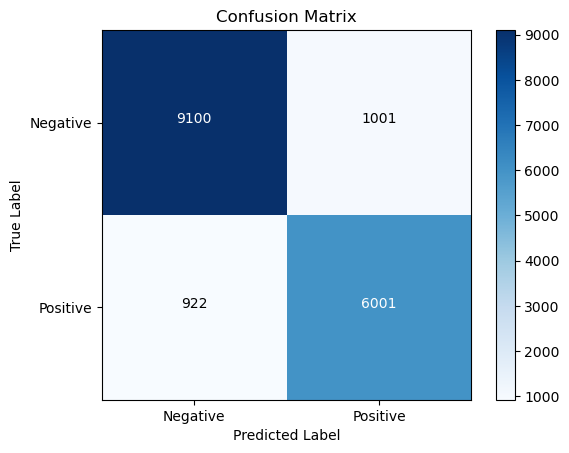

In [57]:
cm = confusion_matrix(y_test, y_pred_w2vvc)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [45]:
import xgboost as xgb
xgb_model=xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=7,
        n_estimators=80,
        use_label_encoder=False,
        eval_metric='auc' )

In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
xgb_model_vectorizer = xgb_model.fit(x_train_flattened, y_train)
y_pred_w2vxgb=xgb_model_vectorizer.predict(x_test_flattened)
print(confusion_matrix(y_test,y_pred_w2vxgb))
print (classification_report(y_test, y_pred_w2vxgb))

[[9753  348]
 [1294 5629]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     10101
           1       0.94      0.81      0.87      6923

    accuracy                           0.90     17024
   macro avg       0.91      0.89      0.90     17024
weighted avg       0.91      0.90      0.90     17024



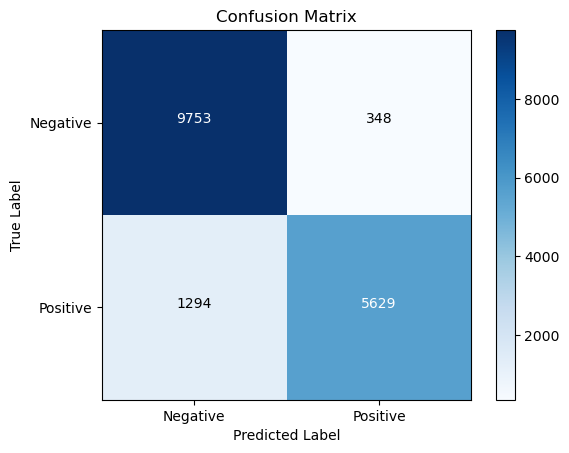

In [47]:
cm = confusion_matrix(y_test, y_pred_w2vxgb)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

count = CountVectorizer(stop_words='english', ngram_range=(1,5))
x_train_vectorizer=count.fit_transform(x_train)

In [43]:
x_test_vectorizer=count.transform(x_test)
x_train_vectorizer.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [44]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()

x_train_tfidf = tfidf.fit_transform(x_train_vectorizer)

x_train_tfidf.toarray()
x_test_tfidf = tfidf.transform(x_test_vectorizer)

In [45]:
x_train_tfidf

<39721x745368 sparse matrix of type '<class 'numpy.float64'>'
	with 1113633 stored elements in Compressed Sparse Row format>

In [46]:
x_test_tfidf

<17024x745368 sparse matrix of type '<class 'numpy.float64'>'
	with 184724 stored elements in Compressed Sparse Row format>

In [55]:
from sklearn.neighbors import KNeighborsClassifier

# create a KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# fit the model on the training data
knn.fit(x_train_tfidf, y_train)

# predict on the test data
y_pred_knn = knn.predict(x_test_tfidf)

# evaluate the model
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Accuracy: 0.6264685150375939
              precision    recall  f1-score   support

           0       0.62      0.98      0.76     10101
           1       0.81      0.11      0.19      6923

    accuracy                           0.63     17024
   macro avg       0.71      0.54      0.47     17024
weighted avg       0.69      0.63      0.53     17024



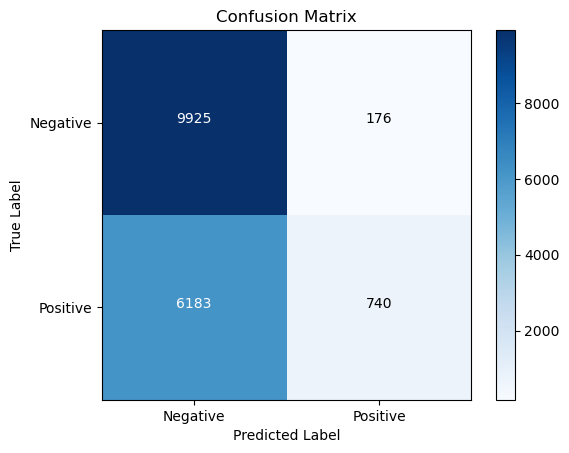

In [56]:
cm = confusion_matrix(y_test, y_pred_knn)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [57]:
from sklearn.neighbors import KNeighborsClassifier

# create a KNN model with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# fit the model on the training data
knn.fit(x_train_vectorizer, y_train)

# predict on the test data
y_pred_knn = knn.predict(x_test_vectorizer)

# evaluate the model
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Accuracy: 0.9017269736842105
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     10101
           1       0.96      0.79      0.87      6923

    accuracy                           0.90     17024
   macro avg       0.92      0.88      0.89     17024
weighted avg       0.91      0.90      0.90     17024



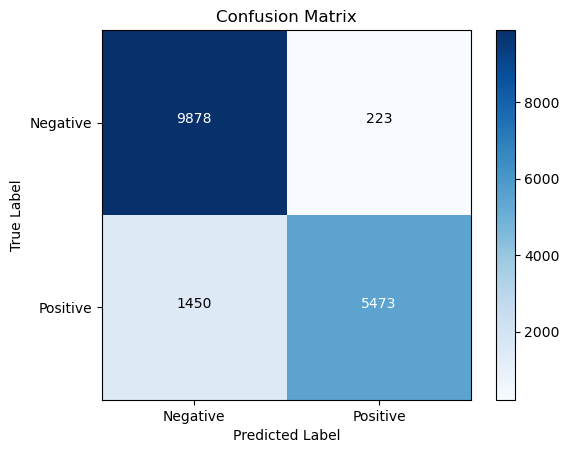

In [59]:
cm = confusion_matrix(y_test, y_pred_knn)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [61]:
model_vectorizer= LogisticRegression().fit(x_train_vectorizer, y_train)
prediction_vectorizer=model_vectorizer.predict(x_test_vectorizer)
print(confusion_matrix(y_test, prediction_vectorizer))
print (classification_report(y_test,prediction_vectorizer))

[[9921  180]
 [ 769 6154]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10101
           1       0.97      0.89      0.93      6923

    accuracy                           0.94     17024
   macro avg       0.95      0.94      0.94     17024
weighted avg       0.95      0.94      0.94     17024



/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


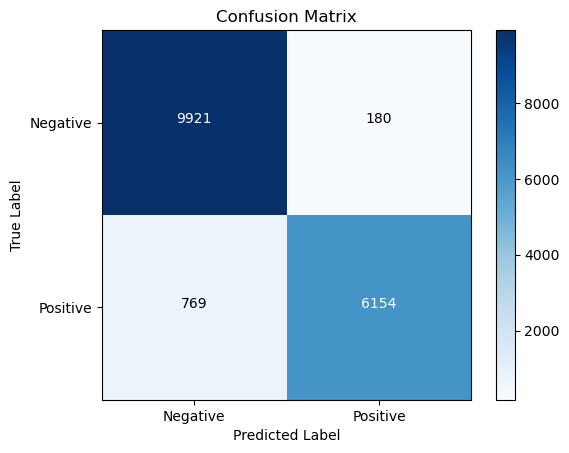

In [62]:
cm = confusion_matrix(y_test, prediction_vectorizer)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [63]:
model_tfidf= LogisticRegression().fit(x_train_tfidf, y_train)
prediction_tfidf=model_tfidf.predict(x_test_tfidf)
print (classification_report(y_test, prediction_tfidf))
print(confusion_matrix(y_test,prediction_tfidf))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10101
           1       0.93      0.90      0.91      6923

    accuracy                           0.93     17024
   macro avg       0.93      0.92      0.93     17024
weighted avg       0.93      0.93      0.93     17024

[[9611  490]
 [ 713 6210]]


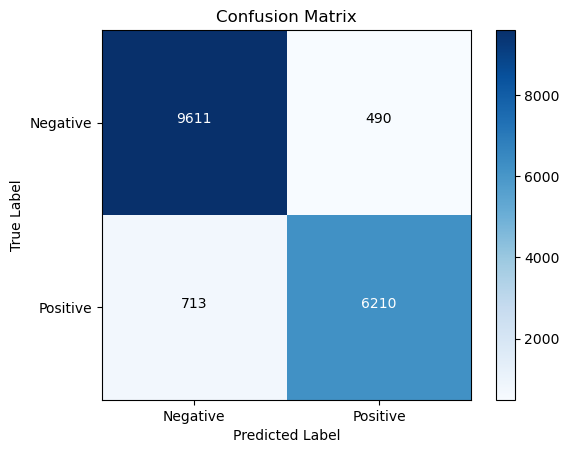

In [64]:
cm = confusion_matrix(y_test, prediction_tfidf)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [65]:
model_vectorizer= DecisionTreeClassifier().fit(x_train_vectorizer, y_train)
prediction_vectorizer_dt=model_vectorizer.predict(x_test_vectorizer)
print(confusion_matrix(y_test, prediction_vectorizer_dt))
print (classification_report(y_test,prediction_vectorizer_dt))

[[9634  467]
 [ 626 6297]]
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     10101
           1       0.93      0.91      0.92      6923

    accuracy                           0.94     17024
   macro avg       0.93      0.93      0.93     17024
weighted avg       0.94      0.94      0.94     17024



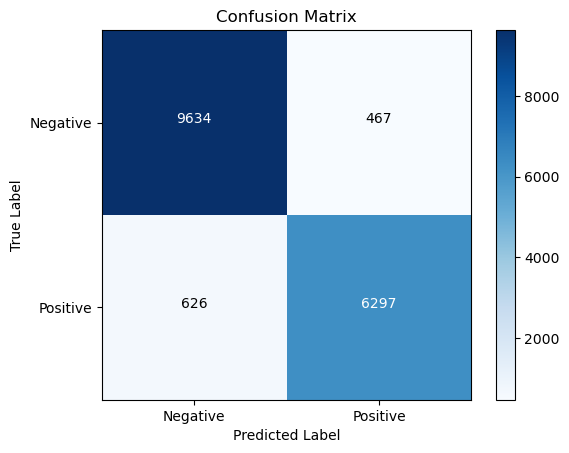

In [67]:
cm = confusion_matrix(y_test, prediction_vectorizer_dt)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [68]:
model_tfidf= DecisionTreeClassifier().fit(x_train_tfidf, y_train)
prediction_tfidf_dt=model_tfidf.predict(x_test_tfidf)
print (classification_report(y_test, prediction_tfidf_dt))
print(confusion_matrix(y_test,prediction_tfidf_dt))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94     10101
           1       0.91      0.91      0.91      6923

    accuracy                           0.93     17024
   macro avg       0.92      0.92      0.92     17024
weighted avg       0.93      0.93      0.93     17024

[[9438  663]
 [ 600 6323]]


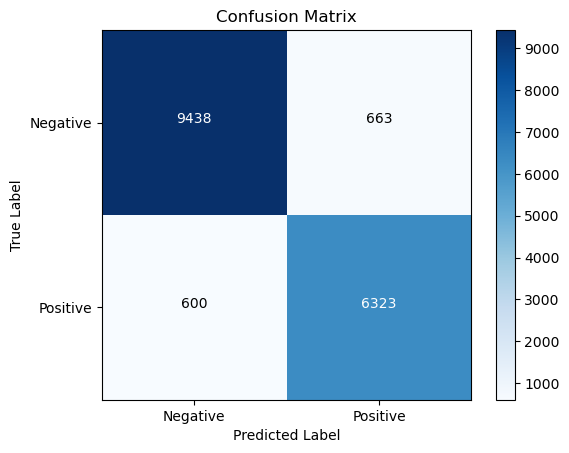

In [69]:
cm = confusion_matrix(y_test, prediction_tfidf_dt)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [49]:
#Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_vectorizer, y_train)
y_pred = clf.predict(x_test_vectorizer)
print(confusion_matrix(y_test,y_pred))
print (classification_report(y_test, y_pred))

[[9728  373]
 [ 715 6208]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95     10101
           1       0.94      0.90      0.92      6923

    accuracy                           0.94     17024
   macro avg       0.94      0.93      0.93     17024
weighted avg       0.94      0.94      0.94     17024



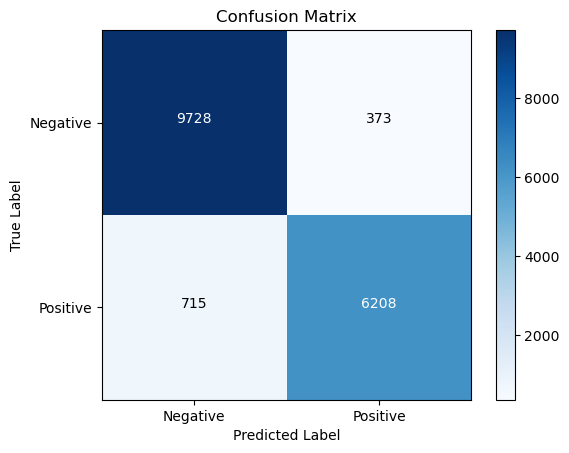

In [66]:
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [70]:
#Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_tfidf, y_train)
y_pred_rf = clf.predict(x_test_tfidf)
print(confusion_matrix(y_test,y_pred_rf))
print (classification_report(y_test, y_pred_rf))

[[9701  400]
 [ 751 6172]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10101
           1       0.94      0.89      0.91      6923

    accuracy                           0.93     17024
   macro avg       0.93      0.93      0.93     17024
weighted avg       0.93      0.93      0.93     17024



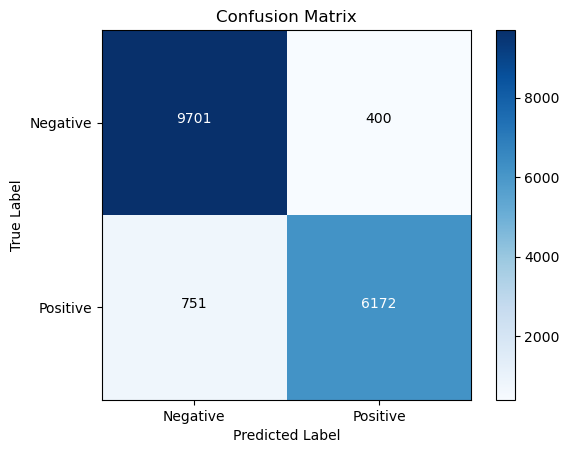

In [71]:
cm = confusion_matrix(y_test, y_pred_rf)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [72]:
model_vectorizer= MultinomialNB().fit(x_train_vectorizer, y_train)
prediction_vectorizer_nb=model_vectorizer.predict(x_test_vectorizer)
print(confusion_matrix(y_test,prediction_vectorizer_nb))
print (classification_report(y_test, prediction_vectorizer_nb))

[[9442  659]
 [ 542 6381]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     10101
           1       0.91      0.92      0.91      6923

    accuracy                           0.93     17024
   macro avg       0.93      0.93      0.93     17024
weighted avg       0.93      0.93      0.93     17024



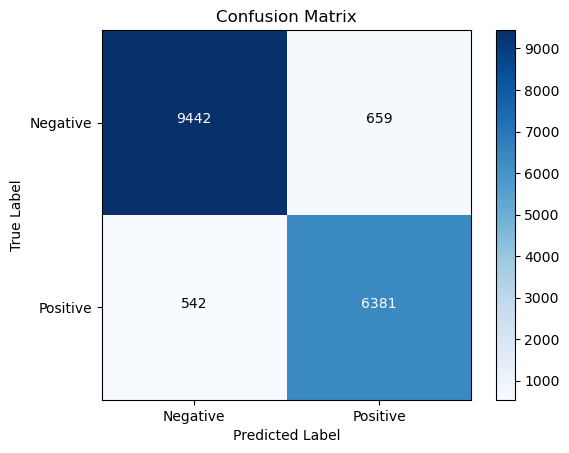

In [73]:
cm = confusion_matrix(y_test, prediction_vectorizer_nb)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [74]:
model_tfidf= MultinomialNB().fit(x_train_tfidf, y_train)
prediction_tfidf_nb=model_tfidf.predict(x_test_tfidf)
print (classification_report(y_test, prediction_tfidf_nb))
print(confusion_matrix(y_test,prediction_tfidf_nb))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94     10101
           1       0.96      0.85      0.90      6923

    accuracy                           0.92     17024
   macro avg       0.93      0.91      0.92     17024
weighted avg       0.93      0.92      0.92     17024

[[9837  264]
 [1041 5882]]


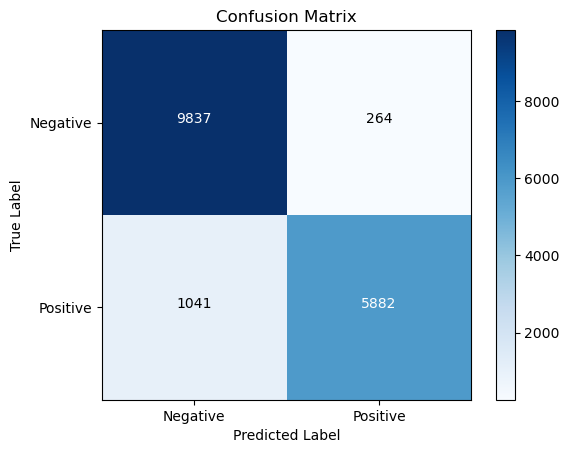

In [75]:
cm = confusion_matrix(y_test, prediction_tfidf_nb)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [76]:
from sklearn.ensemble import VotingClassifier

log_reg = LogisticRegression()
nb = MultinomialNB()
dt = DecisionTreeClassifier()

In [77]:
ensemble = VotingClassifier(estimators=[('lr', log_reg), ('nb', nb), ('dt', dt)], voting='hard')
ensemble.fit(x_train_tfidf, y_train)

# Make predictions on test set
y_pred_vc = ensemble.predict(x_test_tfidf)

print (classification_report(y_test, y_pred_vc))
print(confusion_matrix(y_test,y_pred_vc))


              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10101
           1       0.95      0.90      0.93      6923

    accuracy                           0.94     17024
   macro avg       0.94      0.93      0.94     17024
weighted avg       0.94      0.94      0.94     17024

[[9776  325]
 [ 683 6240]]


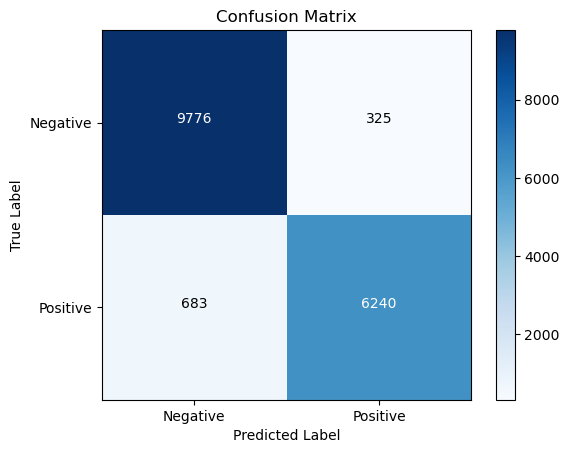

In [78]:
cm = confusion_matrix(y_test, y_pred_vc)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [53]:
ensemble = VotingClassifier(estimators=[('lr', log_reg), ('nb', nb), ('dt', dt)], voting='hard')
ensemble.fit(x_train_vectorizer, y_train)

# Make predictions on test set
y_pred_vc = ensemble.predict(x_test_vectorizer)

print (classification_report(y_test, y_pred_vc))
print(confusion_matrix(y_test,y_pred_vc))


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10101
           1       0.96      0.91      0.93      6923

    accuracy                           0.95     17024
   macro avg       0.95      0.94      0.95     17024
weighted avg       0.95      0.95      0.95     17024

[[9860  241]
 [ 652 6271]]


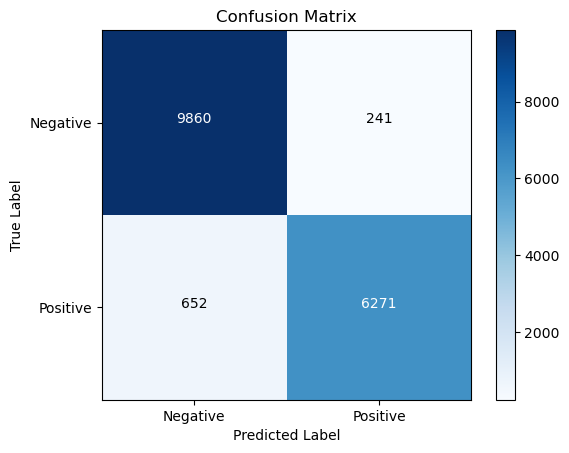

In [54]:
cm = confusion_matrix(y_test, y_pred_vc)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [80]:
import xgboost as xgb
xgb_model=xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=7,
        n_estimators=80,
        use_label_encoder=False,
        eval_metric='auc' )

In [81]:
xgb_model_vectorizer = xgb_model.fit(x_train_vectorizer, y_train)
xgb_predictions_vectorizer=xgb_model_vectorizer.predict(x_test_vectorizer)
print(confusion_matrix(y_test,xgb_predictions_vectorizer))
print (classification_report(y_test, xgb_predictions_vectorizer))

[[9991  110]
 [1104 5819]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     10101
           1       0.98      0.84      0.91      6923

    accuracy                           0.93     17024
   macro avg       0.94      0.91      0.92     17024
weighted avg       0.93      0.93      0.93     17024



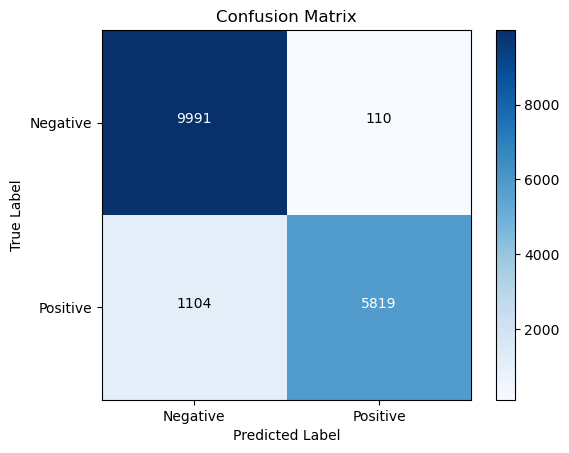

In [82]:
cm = confusion_matrix(y_test, xgb_predictions_vectorizer)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [83]:
xgb_model = xgb_model.fit(x_train_tfidf, y_train)
xgb_predictions=xgb_model.predict(x_test_tfidf)
print(confusion_matrix(y_test,xgb_predictions))
print (classification_report(y_test, xgb_predictions))

[[9979  122]
 [1110 5813]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     10101
           1       0.98      0.84      0.90      6923

    accuracy                           0.93     17024
   macro avg       0.94      0.91      0.92     17024
weighted avg       0.93      0.93      0.93     17024



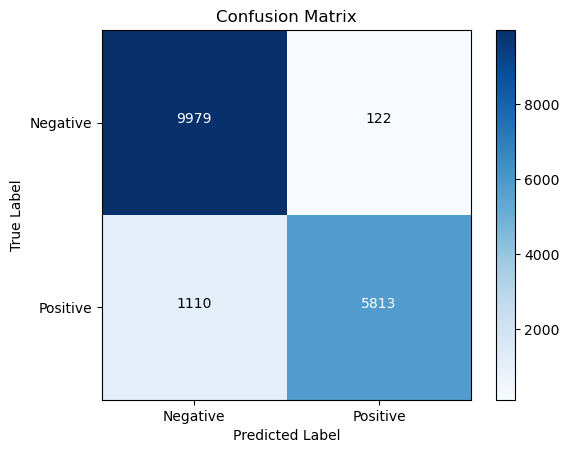

In [84]:
cm = confusion_matrix(y_test, xgb_predictions)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [85]:
from keras.models import Model
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding,SpatialDropout1D
from tensorflow.keras.optimizers import RMSprop
from keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.models import Sequential

In [86]:
print(type(x_train_vectorizer))
print(x_train_vectorizer[:5])

<class 'scipy.sparse.csr.csr_matrix'>
  (0, 108672)	1
  (0, 108700)	1
  (0, 108701)	1
  (0, 108702)	1
  (0, 108703)	1
  (0, 108896)	1
  (0, 108937)	1
  (0, 108938)	1
  (0, 108939)	1
  (0, 204754)	1
  (0, 204755)	1
  (0, 204756)	1
  (0, 264302)	2
  (0, 264986)	1
  (0, 264987)	1
  (0, 264988)	1
  (0, 264989)	1
  (0, 265947)	1
  (0, 265953)	1
  (0, 265954)	1
  (0, 265955)	1
  (0, 409376)	1
  (0, 543138)	1
  (0, 543155)	1
  (1, 60323)	1
  :	:
  (4, 213359)	1
  (4, 213443)	1
  (4, 213444)	1
  (4, 213445)	1
  (4, 213446)	1
  (4, 317564)	1
  (4, 346803)	1
  (4, 348073)	1
  (4, 348083)	1
  (4, 348084)	1
  (4, 348085)	1
  (4, 613890)	1
  (4, 614820)	1
  (4, 614824)	1
  (4, 614825)	1
  (4, 614826)	1
  (4, 653080)	1
  (4, 653145)	1
  (4, 653146)	1
  (4, 653147)	1
  (4, 729656)	1
  (4, 729924)	1
  (4, 729925)	1
  (4, 729926)	1
  (4, 729927)	1


In [87]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
x_train_list = [str(x) for x in x_train_vectorizer]
max_words = 52000
max_len = 300
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train_list)
sequences = tokenizer.texts_to_sequences(x_train_list)
sequences_matrix = pad_sequences(sequences,maxlen=max_len)

In [88]:
model = Sequential()
model.add(Embedding(max_words, 100, input_length=max_len))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(200, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 100)          5200000   
                                                                 
 spatial_dropout1d (SpatialD  (None, 300, 100)         0         
 ropout1D)                                                       
                                                                 
 lstm (LSTM)                 (None, 200)               240800    
                                                                 
 dense (Dense)               (None, 1)                 201       
                                                                 
Total params: 5,441,001
Trainable params: 5,441,001
Non-trainable params: 0
_________________________________________________________________


In [97]:
from keras.callbacks import EarlyStopping,ModelCheckpoint

stop = EarlyStopping(
    monitor='val_accuracy', 
    mode='max',
    patience=5
)

checkpoint= ModelCheckpoint(
    filepath='./',
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

In [98]:
#with early-stopping
model_instance = model.fit(sequences_matrix,y_train,batch_size=1024,epochs=10,
          validation_split=0.25,callbacks=[stop,checkpoint])
#without early-stopping
#history=model.fit(sequences_matrix,y_train,batch_size=1024,epochs=15,
 #         validation_split=0.1,callbacks=[checkpoint])

Epoch 1/10
30/30 [==============================] - 40s 1s/step - loss: 0.1761 - accuracy: 0.9427 - val_loss: 0.2445 - val_accuracy: 0.9301
Epoch 2/10
30/30 [==============================] - 41s 1s/step - loss: 0.1746 - accuracy: 0.9419 - val_loss: 0.1913 - val_accuracy: 0.9342
Epoch 3/10
30/30 [==============================] - 41s 1s/step - loss: 0.1668 - accuracy: 0.9449 - val_loss: 0.1957 - val_accuracy: 0.9331
Epoch 4/10
30/30 [==============================] - 40s 1s/step - loss: 0.1653 - accuracy: 0.9470 - val_loss: 0.1928 - val_accuracy: 0.9392
Epoch 5/10
30/30 [==============================] - 40s 1s/step - loss: 0.1572 - accuracy: 0.9499 - val_loss: 0.1886 - val_accuracy: 0.9384
Epoch 6/10
30/30 [==============================] - 40s 1s/step - loss: 0.1594 - accuracy: 0.9491 - val_loss: 0.1752 - val_accuracy: 0.9403
Epoch 7/10
30/30 [==============================] - 41s 1s/step - loss: 0.1469 - accuracy: 0.9514 - val_loss: 0.2216 - val_accuracy: 0.9358
Epoch 8/10
30/30 [==

In [99]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# convert test data to list of strings
x_test_list = [str(x) for x in x_test_vectorizer]

# convert test data to sequences and pad sequences
test_sequences = tokenizer.texts_to_sequences(x_test_list)
test_sequences_matrix = pad_sequences(test_sequences, maxlen=max_len)

# generate predicted labels
y_pred = model.predict(test_sequences_matrix)
y_pred_classes = [1 if pred > 0.5 else 0 for pred in y_pred]

# calculate classification metrics and confusion matrix
print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))


532/532 [==============================] - 38s 71ms/step
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     10101
           1       0.92      0.92      0.92      6923

    accuracy                           0.94     17024
   macro avg       0.93      0.93      0.93     17024
weighted avg       0.94      0.94      0.94     17024

[[9564  537]
 [ 559 6364]]


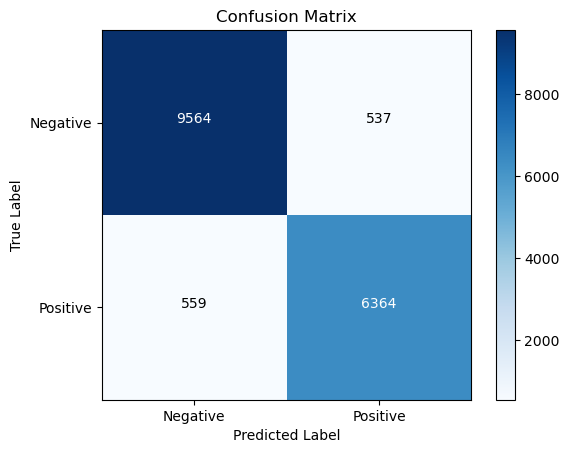

In [100]:
cm = confusion_matrix(y_test, y_pred_classes)

# Visualize confusion matrix
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Negative', 'Positive'])
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add labels to each cell
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.show()

In [101]:
model_instance.history

{'loss': [0.1761171817779541,
  0.17456328868865967,
  0.16682203114032745,
  0.16529390215873718,
  0.15721836686134338,
  0.1594424694776535,
  0.1469404101371765,
  0.14408037066459656,
  0.14292535185813904,
  0.14160266518592834],
 'accuracy': [0.9427324533462524,
  0.9418932795524597,
  0.9448808431625366,
  0.9469620585441589,
  0.9498825073242188,
  0.9490768909454346,
  0.9513930678367615,
  0.9534743428230286,
  0.9532057642936707,
  0.955286979675293],
 'val_loss': [0.2444860190153122,
  0.19127845764160156,
  0.19569820165634155,
  0.19281770288944244,
  0.188630610704422,
  0.17517317831516266,
  0.22157344222068787,
  0.17424002289772034,
  0.2603706419467926,
  0.1877518743276596],
 'val_accuracy': [0.9301177859306335,
  0.934246301651001,
  0.9331386685371399,
  0.9391803741455078,
  0.9383747577667236,
  0.9402880072593689,
  0.9357567429542542,
  0.9389789700508118,
  0.9253851771354675,
  0.9341456294059753]}